In [3]:
import xarray as xr

ds_idealized_100d= xr.open_dataset('../snap_idealized_100d.cdf')


In [31]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.linalg import eigh, LinAlgError
from scipy.integrate import cumtrapz
from scipy import fft

def vertical_mode_decomposition(z, N2, f0, boundary='rigid_lid', n_modes=10):
    """
    Compute vertical modes for given stratification and boundary conditions.
    
    Parameters:
    z: depth array (positive downward)
    N2: buoyancy frequency squared
    f0: Coriolis parameter
    boundary: boundary condition ('rigid_lid' or 'free_surface')
    n_modes: number of modes to compute
    
    Returns:
    h_modes: eigenvalues (equivalent depths)
    F_modes: vertical structure functions for horizontal velocity
    G_modes: vertical structure functions for vertical velocity
    """
    
    nz = len(z)
    dz = np.diff(z)
    
    # Create second derivative matrix with appropriate boundary conditions
    D2 = np.zeros((nz, nz))
    
    # Interior points (centered difference)
    for i in range(1, nz-1):
        D2[i, i-1] = 1.0 / (dz[i-1] * 0.5*(dz[i-1] + dz[i]))
        D2[i, i] = -2.0 / (dz[i-1] * dz[i])
        D2[i, i+1] = 1.0 / (dz[i] * 0.5*(dz[i-1] + dz[i]))
    
    # Apply boundary conditions
    if boundary == 'rigid_lid':
        # w = 0 at surface and bottom → G = 0
        D2[0, :] = 0  # Surface boundary condition
        D2[0, 0] = 1.0  # Dirichlet condition
        D2[-1, :] = 0  # Bottom boundary condition  
        D2[-1, -1] = 1.0  # Dirichlet condition
        
    elif boundary == 'free_surface':
        # w = 0 at bottom, dw/dz = 0 at surface
        D2[0, :] = 0  # Surface: Neumann condition
        D2[0, 0] = -1.0 / dz[0]
        D2[0, 1] = 1.0 / dz[0]
        D2[-1, :] = 0  # Bottom: Dirichlet condition
        D2[-1, -1] = 1.0
    
    # Create the eigenvalue problem: d²G/dz² + (N²/c²)G = 0
    # Or equivalently: d²G/dz² = -λ G, where λ = N²/c²
    
    # Since N² varies with depth, we need to solve generalized eigenvalue problem
    # D2 @ G = -λ diag(1/N²) @ G
    
    # Create the matrix for the generalized eigenvalue problem
    A = D2
    B = np.diag(-1.0 / N2)  # Note the negative sign
    
    # Solve generalized eigenvalue problem
    try:
        eigenvalues, eigenvectors = eigh(A, B)
    except LinAlgError:
        print("Eigenvalue solution failed")
        return None, None, None
    
    # Sort eigenvalues and eigenvectors (ascending order)
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Extract the first n_modes
    h_modes = 1.0 / eigenvalues[:n_modes]  # Equivalent depths
    G_modes = eigenvectors[:, :n_modes]  # Vertical velocity modes
    
    # Normalize modes (L2 norm = 1)
    for i in range(n_modes):
        G_modes[:, i] /= np.sqrt(np.trapz(G_modes[:, i]**2, z))
    
    # Compute F modes (horizontal velocity modes) from G modes
    F_modes = np.zeros_like(G_modes)
    for i in range(n_modes):
        # F = (1/h) ∫ G dz from bottom to z
        F_modes[:, i] = cumtrapz(G_modes[:, i], z, initial=0) / h_modes[i]
    
    return h_modes, F_modes, G_modes

def project_field_onto_modes(field, G_modes, z, norm='energy'):
    """
    Project a velocity field onto vertical modes.
    
    Parameters:
    -----------
    field : array
        Velocity field to project (u, v, or w)
    G_modes : array
        Vertical mode structure functions
    z : array
        Vertical coordinate
    norm : str
        Normalization method
        
    Returns:
    --------
    coefficients : array
        Mode coefficients
    """
    n_modes = G_modes.shape[1]
    coefficients = np.zeros(n_modes)
    
    # Simple L2 projection
    dz = np.abs(z[1] - z[0])
    for i in range(n_modes):
        # Normalize mode
        mode_norm = np.sqrt(np.sum(G_modes[:, i]**2) * dz)
        if mode_norm > 0:
            normalized_mode = G_modes[:, i] / mode_norm
            coefficients[i] = np.sum(field * normalized_mode) * dz
            
    return coefficients

def reconstruct_from_modes(coefficients, modes, z):
    """
    Reconstruct field from modal coefficients.
    
    Parameters:
    -----------
    coefficients : array
        Modal coefficients
    modes : array
        Mode structure functions
    z : array
        Vertical coordinate
        
    Returns:
    --------
    reconstructed : array
        Reconstructed field
    """
    reconstructed = np.zeros(len(z))
    dz = np.abs(z[1] - z[0])
    
    for i, coeff in enumerate(coefficients):
        if i < modes.shape[1]:
            # Normalize mode
            mode_norm = np.sqrt(np.sum(modes[:, i]**2) * dz)
            if mode_norm > 0:
                normalized_mode = modes[:, i] / mode_norm
                reconstructed += coeff * normalized_mode
                
    return reconstructed

"""# Example usage and testing
def example_usage():
    # Create example stratification
    z = ds_idealized_100d['z']  
    
    # Exponential stratification: N² = N₀² exp(2z/b)
    
    f0      = 0.100000E-03 #1/s
    N0      = 0.300000E-02 #1/s
    b = 1300  # thermocline depth scale
    N2 = N0**2 * np.exp(2*z/b)
    
    
    # Compute modes
    h_modes, F_modes, G_modes = vertical_mode_decomposition(
        z, N2, f0, boundary='rigid_lid', n_modes=5
    )
    
    if h_modes is not None:
        print("Equivalent depths (m):")
        for i, h in enumerate(h_modes):
            print(f"Mode {i+1}: {h:.1f} m")
            
        # Plot first few modes
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
        
        # Stratification
        ax1.plot(N2*1e6, z/1000)
        ax1.set_xlabel('N² (×10⁻⁶ s⁻²)')
        ax1.set_ylabel('Depth (km)')
        ax1.set_title('Stratification')
        ax1.grid(True)
        
        # G modes (vertical velocity structure)
        for i in range(min(3, len(h_modes))):
            ax2.plot(G_modes[:, i], z/1000, label=f'Mode {i+1}')
        ax2.set_xlabel('G (vertical structure)')
        ax2.set_ylabel('Depth (km)')
        ax2.set_title('G Modes')
        ax2.legend()
        ax2.grid(True)
        
        # F modes (horizontal velocity structure)  
        for i in range(min(3, len(h_modes))):
            ax3.plot(F_modes[:, i], z/1000, label=f'Mode {i+1}')
        ax3.set_xlabel('F (horizontal structure)')
        ax3.set_ylabel('Depth (km)')
        ax3.set_title('F Modes')
        ax3.legend()
        ax3.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        return z, N2, h_modes, F_modes, G_modes
    else:
        print("Mode computation failed")
        return None
"""
def decompose_velocity_field(u, v, w, p, b, z, N2, f0=1e-4):
    """
    Decompose velocity fields u,v,w,p,b onto vertical modes.
    
    Parameters:
    -----------
    u, v, w : arrays
        Velocity components (assume 1D vertical profiles)
    p : array  
        Pressure field
    b : array
        Buoyancy field
    z : array
        Vertical coordinate
    N2 : array
        Background stratification N²(z)
    f0 : float
        Coriolis parameter
        
    Returns:
    --------
    mode_decomposition : dict
        Dictionary containing modal coefficients and reconstructions
    """
    
    # Compute vertical modes
    h_modes, F_modes, G_modes = vertical_mode_decomposition(
        z, N2, f0, boundary='rigid_lid', n_modes=10
    )
    
    if h_modes is None:
        return None
        
    # Project velocity components onto modes
    # u,v project onto F modes (horizontal velocity structure)
    # w projects onto G modes (vertical velocity structure)
    
    u_coeffs = project_field_onto_modes(u, F_modes, z)
    v_coeffs = project_field_onto_modes(v, F_modes, z) 
    w_coeffs = project_field_onto_modes(w, G_modes, z)
    
    # For pressure and buoyancy, use appropriate mode structure
    p_coeffs = project_field_onto_modes(p, F_modes, z)
    b_coeffs = project_field_onto_modes(b, G_modes, z)
    
    # Reconstruct fields
    u_recon = reconstruct_from_modes(u_coeffs, F_modes, z)
    v_recon = reconstruct_from_modes(v_coeffs, F_modes, z)
    w_recon = reconstruct_from_modes(w_coeffs, G_modes, z)
    p_recon = reconstruct_from_modes(p_coeffs, F_modes, z)
    b_recon = reconstruct_from_modes(b_coeffs, G_modes, z)
    
    return {
        'h_modes': h_modes,
        'F_modes': F_modes, 
        'G_modes': G_modes,
        'coefficients': {
            'u': u_coeffs, 'v': v_coeffs, 'w': w_coeffs,
            'p': p_coeffs, 'b': b_coeffs
        },
        'reconstructed': {
            'u': u_recon, 'v': v_recon, 'w': w_recon,
            'p': p_recon, 'b': b_recon
        },
        'original': {
            'u': u, 'v': v, 'w': w, 'p': p, 'b': b
        }
    }


ImportError: cannot import name 'cumtrapz' from 'scipy.integrate' (/home/u/u241366/.conda/envs/test/lib/python3.12/site-packages/scipy/integrate/__init__.py)

In [ ]:
z = ds_idealized_100d['z']
f0      = 0.100000E-03 #1/s
N0      = 0.300000E-02 #1/s
b = 1300  # thermocline depth scale
N2 = N0**2 * np.exp(2*z/b)
u = ds_idealized_100d['u']
v = ds_idealized_100d['v']
w = ds_idealized_100d['w']
p = ds_idealized_100d['p']
b_field = ds_idealized_100d['b']   

decompose_velocity_field(u, v, w, p, b_field, z, N2, f0)

NameError: name 'LinAlgError' is not defined

CGL Points: [ 1.00000000e+00  9.80785280e-01  9.23879533e-01  8.31469612e-01
  7.07106781e-01  5.55570233e-01  3.82683432e-01  1.95090322e-01
  6.12323400e-17 -1.95090322e-01 -3.82683432e-01 -5.55570233e-01
 -7.07106781e-01 -8.31469612e-01 -9.23879533e-01 -9.80785280e-01
 -1.00000000e+00]


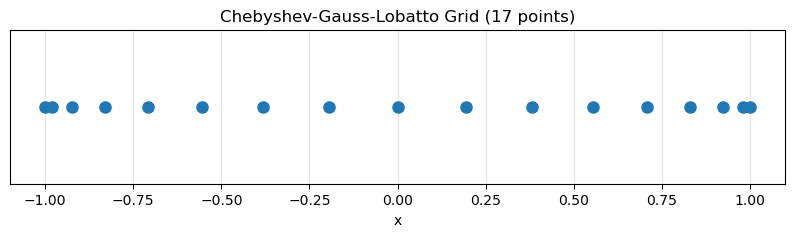

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def chebyshev_gauss_lobatto_grid(n):
    """
    Generates a Chebyshev-Gauss-Lobatto grid of n+1 points on the interval [-1, 1].
    
    Parameters:
    n (int): The order of the polynomial. The number of points is N = n + 1.
    
    Returns:
    numpy.ndarray: The CGL grid points.
    """
    # The formula: x_j = cos(π * j / n) for j = 0, 1, ..., n
    j = np.arange(0, n+1)
    x = np.cos(np.pi * j / n)
    return x

# Example: Create a grid with 17 points (n=16)
n = 16
cgl_points = chebyshev_gauss_lobatto_grid(n)

print("CGL Points:", cgl_points)

# Visualize the grid to see the non-uniform clustering
plt.figure(figsize=(10, 2))
plt.plot(cgl_points, np.zeros_like(cgl_points), 'o', markersize=8)
plt.title(f'Chebyshev-Gauss-Lobatto Grid ({n+1} points)')
plt.xlabel('x')
plt.yticks([])
plt.grid(True, alpha=0.3)
plt.show()